# First Steps Towards Stochastic Expectation-Maximization

In this notebook, I'll describe and demonstrate an early version of *stochastic expectation maximization* (SEM), a technique that I learned about primarily from [this paper](https://proceedings.neurips.cc/paper_files/paper/2018/hash/aba22f748b1a6dff75bda4fd1ee9fe07-Abstract.html). This framework applies when the joint distribution between latent and observed variables is in an exponential family, which is indeed true in our case. 

### SEM

I implemented the calculation of the basic SEM update. This update consists in performing an EM-like parameter update using a *single* edge and modifying the current estimate accordingly. Suppose that we have a current estimate $\hat{\theta}^{(t)}$ at time $t$, and that in step $t+1$ we get an update $\theta'$. Then, the basic new estimate in the SEM framework is 

$$
\hat{\theta}^{(t+1)}  = (1-\rho^{(t)})\hat{\theta}^{(t)} + \rho^{(t)}\theta'. 
$$

We can think of $\rho^{(t)}$ as a learning rate that tunes how quickly the parameter update occurs. As in other optimization frameworks, it is possible to choose $\rho^{(t)}$ to decrease over time. In the cited paper above, the authors instead take a different approach in which they modify the update in order to make it unnecessary to tune the learning rate. 

### *What I Did*

I implemented the *simplest* version of SEM. In this version, we first sample an edge $e$. From $e$, we then compute a vector of *expected sufficient statistics* with respect to the distribution over possible edges that could have generated $e$. These expectations summarize the important features of the data. From these expectations, it is then possible to form the update $\theta'$, after which we can iterate the equation above until (hopefully) convergence. 

The approach I used involves an approximation: we approximate that the number of nodes added from the remainder of the hypergraph is Poisson with expectation $\gamma$, rather than binomial with parameter $\gamma/N$. This *should* be ok when $N$ is large. Because the algorithm doesn't seem to be working perfectly, this is one thing that we might want to take another look at later. 

### *Findings*

So far, what I've found is that *this works sometimes*. In particular, there are settings of the parameters where this algorithm performs very well, in practical time, on large hypergraphs. Here's an example of estimating the parameters on a hypergraph with 1M edges and roughly 1M nodes. 

In [5]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") # my implementation of baby SEM
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np

In [6]:
# generate some sample data

eta   = 0.7   # node retention in edges
beta  = 1.2   # poisson number of novel nodes
gamma = 0.8   # poisson number of nodes from graph

timesteps = int(1e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

This hypergraph has 10002 edges and 11910 nodes.


In [7]:
# initialize a model with 
# initial parameter guesses

init_pars = {"eta"   : 0.3, 
                        "beta"  : 0.4, 
                        "gamma" : 0.02}
EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars)

In [9]:
# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

# main loop
for i in range(steps):

    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
        
        
    EM.SEM_step(0.002) # both the stochastic E and the M steps are in here
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])

--------
Completed step 0
{'eta': 0.3, 'beta': 0.4, 'gamma': 0.02}
--------
Completed step 250
{'eta': 0.4387635938401264, 'beta': 0.6831958126469377, 'gamma': 0.3051236388219263}
--------
Completed step 500
{'eta': 0.5359752199975419, 'beta': 0.8798862519487267, 'gamma': 0.5102785639892062}
--------
Completed step 750
{'eta': 0.6009362161612478, 'beta': 1.0433132031410874, 'gamma': 0.6361833619668648}
--------
Completed step 1000
{'eta': 0.6379646446429631, 'beta': 1.109642655057947, 'gamma': 0.7022104756460366}
--------
Completed step 1250
{'eta': 0.6631340587503972, 'beta': 1.1597788214109026, 'gamma': 0.7161405979834428}
--------
Completed step 1500
{'eta': 0.6764116692559019, 'beta': 1.1544307323475567, 'gamma': 0.7778409657639676}
--------
Completed step 1750
{'eta': 0.6859530948167816, 'beta': 1.1547862709770034, 'gamma': 0.7661098087267961}
--------
Completed step 2000
{'eta': 0.6878059819496173, 'beta': 1.15104244719222, 'gamma': 0.7880042362183944}
--------
Completed step 225

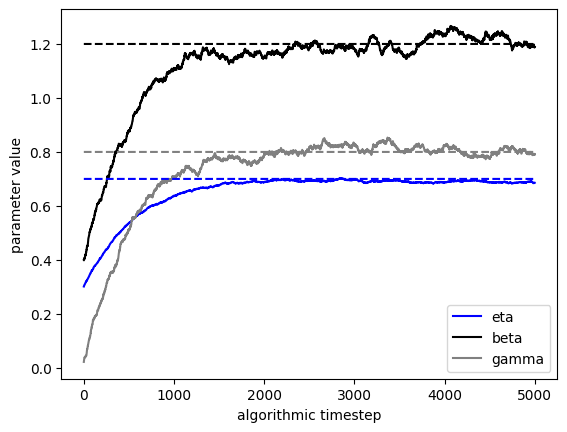

In [10]:
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

That looks pretty promising! 

## A Less Successful Example 

On the other hand, I have also observed cases, especially when the parameters are small, with less good performance. Here's a smaller example: 

In [11]:
# generate some sample data

eta   = 0.6   # node retention in edges
beta  = 0.3   # poisson number of novel nodes
gamma = 0.2   # poisson number of nodes from graph

timesteps = int(10000)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")



This hypergraph has 10002 edges and 2986 nodes.


In [18]:
# initialize a model with 
# initial parameter guesses
EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars, memoize = True)

# track the parameter estimates over time
ETA   = []
BETA  = []
GAMMA = []
steps = 5000

for i in range(steps):

    EM.SEM_step(0.002, min_time=0) # both the stochastic E and the M steps are in here
    if i % 250 == 0:
        print("--------")
        print(f"Completed step {i}")
        print(EM.pars)
    ETA.append(EM.pars["eta"])
    BETA.append(EM.pars["beta"])
    GAMMA.append(EM.pars["gamma"])
    
# how'd we do?     
T = np.arange(steps)
plt.plot(T, ETA,   label = "eta", color = "blue")
plt.plot(T, BETA,  label = "beta", color = "black")
plt.plot(T, GAMMA, label = "gamma", color = "grey")

plt.plot(T, np.ones((steps,))*eta, color = "blue", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*beta, color = "black", linestyle = "dashed")
plt.plot(T, np.ones((steps,))*gamma, color = "grey", linestyle = "dashed")

plt.gca().set(xlabel = "algorithmic timestep", ylabel = "parameter value")
plt.legend()

TypeError: unhashable type: 'numpy.ndarray'

In [16]:
import cProfile
cProfile.run("for i in range(100): EM.SEM_step(0.002, min_time=0)")

         2002992 function calls in 5.112 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    79939    0.073    0.000    0.308    0.000 <__array_function__ internals>:177(concatenate)
        1    0.000    0.000    5.112    5.112 <string>:1(<module>)
   159878    0.263    0.000    0.263    0.000 _basic.py:2747(factorial)
      223    0.000    0.000    0.000    0.000 hypergraph.py:288(nodes)
    80039    0.013    0.000    0.013    0.000 hypergraph.py:293(edges)
    79939    0.179    0.000    0.740    0.000 likelihoods.py:100(novel_nodes_pmf)
    79939    0.190    0.000    0.794    0.000 likelihoods.py:111(nodes_from_hypergraph_pmf)
    79939    0.053    0.000    1.073    0.000 likelihoods.py:23(__call__)
    79939    0.048    0.000    0.787    0.000 likelihoods.py:36(__call__)
    79939    0.051    0.000    0.845    0.000 likelihoods.py:48(__call__)
   159878    0.903    0.000    1.166    0.000 likelihoods.py:64(poisson)
    

In [35]:
(H.edge_size_sequence() == 1).mean()

0.15406918616276744